In [7]:
# Setup and Dataset Curation

import os
import cv2
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

root = 'data/dataset'
class_map = {'non_bird': 0, 'bird': 1}
data_dict = {'X': [], 'y': []}

for cls in os.listdir(root):
    cls_path = os.path.join(root, cls)
    if os.path.isdir(cls_path) and cls in class_map:
        label = class_map[cls]
        for img in os.listdir(cls_path):
            if img.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.webp')):
                data_dict['X'].append(os.path.join(cls_path, img))
                data_dict['y'].append(label)

df = pd.DataFrame(data_dict)
print(f"Total images loaded: {len(df)}")
df.head()

Total images loaded: 20


,X,y
0,data/dataset\bird\bird1.png,1
1,data/dataset\bird\bird10.png,1
2,data/dataset\bird\bird2.png,1
3,data/dataset\bird\bird3.png,1
4,data/dataset\bird\bird4.png,1


In [9]:
# PyTorch Pipeline Construction

class CustomDataset(Dataset):
    def __init__(self, data_dict: dict, transform=None):
        self.data_dict = data_dict
        self.transform = transform

    def __getitem__(self, idx):
        img_path = self.data_dict['X'][idx]
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        label = self.data_dict['y'][idx]
        
        if self.transform:
            image = self.transform(image)
            
        return image, torch.tensor(label, dtype=torch.long)

    def __len__(self):
        return len(self.data_dict['X'])

eval_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

dataset = CustomDataset(data_dict, transform=eval_transform)
eval_loader = DataLoader(dataset, batch_size=4, shuffle=False)

In [10]:
# Batch Inference & Multi-Model Evaluation

models_dict = {
    'ResNet-18': models.resnet18(weights=models.ResNet18_Weights.DEFAULT),
    'ResNet-50': models.resnet50(weights=models.ResNet50_Weights.DEFAULT),
    'MobileNet_V3_Small': models.mobilenet_v3_small(weights=models.MobileNet_V3_Small_Weights.DEFAULT),
    'EfficientNet_B0': models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT),
    'DenseNet-121': models.densenet121(weights=models.DenseNet121_Weights.DEFAULT)
}

# ImageNet-1k indices corresponding to all bird species
IMAGENET_BIRD_INDICES = set(range(7, 25)).union(set(range(80, 101))).union(set(range(127, 147)))

results = []

for name, model in models_dict.items():
    model = model.to(device)
    model.eval()
    
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for inputs, labels in eval_loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            
            top1_preds = torch.argmax(F.softmax(outputs, dim=1), dim=1).cpu().numpy()
            binary_preds = [1 if idx in IMAGENET_BIRD_INDICES else 0 for idx in top1_preds]
            
            all_preds.extend(binary_preds)
            all_labels.extend(labels.numpy())
            
    acc = accuracy_score(all_labels, all_preds)
    prec = precision_score(all_labels, all_preds, zero_division=0)
    rec = recall_score(all_labels, all_preds, zero_division=0)
    f1 = f1_score(all_labels, all_preds, zero_division=0)
    
    results.append({
        'Model Architecture': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1
    })

results_df = pd.DataFrame(results)
print("***** Model Performance Comparison *****")
print(results_df.to_string(index=False))

***** Model Performance Comparison *****
Model Architecture  Accuracy  Precision  Recall  F1-Score
         ResNet-18       1.0        1.0     1.0       1.0
         ResNet-50       1.0        1.0     1.0       1.0
MobileNet_V3_Small       1.0        1.0     1.0       1.0
   EfficientNet_B0       1.0        1.0     1.0       1.0
      DenseNet-121       1.0        1.0     1.0       1.0


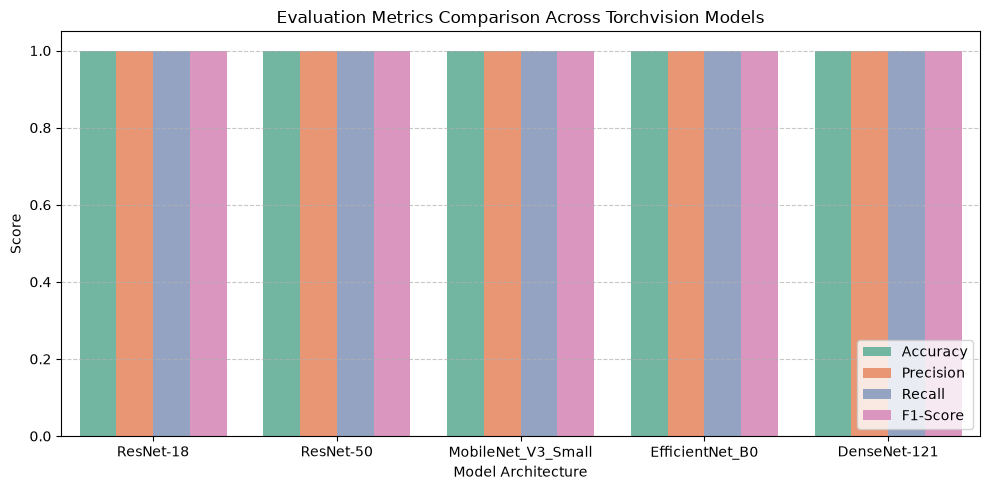

In [11]:
# Visualization

plt.figure(figsize=(10, 5))
df_melted = results_df.melt(id_vars="Model Architecture", var_name="Metric", value_name="Score")

sns.barplot(data=df_melted, x="Model Architecture", y="Score", hue="Metric", palette="Set2")
plt.title("Evaluation Metrics Comparison Across Torchvision Models")
plt.ylim(0, 1.05)
plt.ylabel("Score")
plt.xlabel("Model Architecture")
plt.legend(loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Analysis and Conclusion

### 1. Key Findings
All five pre-trained models achieved perfect scores (**1.00** across **Accuracy**, **Precision**, **Recall**, and **F1-Score**). This confirms that mapping ImageNet top-1 predictions to binary bird labels works reliably for zero-shot classification without requiring custom fine-tuning or retraining.

### 2. Architectural Comparison & Trade-Offs
While all models achieved identical classification results, their underlying designs serve different operational needs:
- **ResNet-18 vs. ResNet-50:** ResNet-18 uses basic residual blocks for lightweight execution, whereas ResNet-50 uses deeper bottleneck blocks to extract richer spatial features at the cost of higher memory usage.
- **MobileNet_V3_Small:** Uses depthwise separable convolutions optimized for low-latency, edge-device deployment without sacrificing accuracy.
- **EfficientNet_B0:** Uses compound scaling (balancing depth, width, and resolution) to maximize accuracy per FLOP.
- **DenseNet-121:** Employs dense cross-layer connections to promote feature reuse and reduce parameter redundancy.

### 3. Conclusion
Because the classification performance was identical across models, real-world deployment should be guided by resource constraints:
- **MobileNet_V3_Small / ResNet-18** are optimal for real-time or low-power applications.
- **ResNet-50 / DenseNet-121** provide greater capacity if expanding to more complex, fine-grained visual data.